In [ ]:
# Cell 1: Install dependencies
!pip install pandas numpy scikit-learn matplotlib seaborn joblib torch

In [ ]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, classification_report)
from sklearn.pipeline import make_pipeline

from matplotlib.patches import Rectangle # Explicitly import Rectangle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Cell 3: Load Data
# Upload your CSV files via the Colab file browser before running this cell

air_df     = pd.read_csv("air_data.csv")
alcohol_df = pd.read_csv("alcohol_data.csv")
coffee_df  = pd.read_csv("coffee_data.csv")
vinegar_df = pd.read_csv("vinegar_data.csv")
wine_df    = pd.read_csv("wine_data.csv")

df = pd.concat([air_df, alcohol_df, coffee_df, vinegar_df, wine_df], ignore_index=True)
print(f"Total samples: {len(df)}")
print(f"Class distribution:")
print(df["label"].value_counts())

Total samples: 2002
Class distribution:
label
alcohol    401
vinegar    401
coffee     401
wine       401
air        398
Name: count, dtype: int64


In [ ]:
# Cell 4: Feature Engineering
# Per-sensor gas resistance (8 features) + log-transformed (8 features) = 16 total

base_cols = [col for col in df.columns if "gas" in col and "index" not in col]

X = df[base_cols].ffill().bfill()
X = X.dropna()

# Add log-transformed features
for col in base_cols:
    X[f"{col}_log"] = np.log1p(X[col])

feature_cols = list(X.columns)
y = df["label"][X.index]

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Shape: {X.shape}")
print(f"Class distribution:")
print(y.value_counts())

Features (16): ['sensor_0_gas', 'sensor_1_gas', 'sensor_2_gas', 'sensor_3_gas', 'sensor_4_gas', 'sensor_5_gas', 'sensor_6_gas', 'sensor_7_gas', 'sensor_0_gas_log', 'sensor_1_gas_log', 'sensor_2_gas_log', 'sensor_3_gas_log', 'sensor_4_gas_log', 'sensor_5_gas_log', 'sensor_6_gas_log', 'sensor_7_gas_log']
Shape: (2002, 16)
Class distribution:
label
alcohol    401
vinegar    401
coffee     401
wine       401
air        398
Name: count, dtype: int64


In [ ]:
# Cell 5: Split and Scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Clean any NaN/inf after scaling (needed for MLP)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)

labels = sorted(y.unique())
print(f"Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
print(f"Classes: {labels}")

Train: (1601, 16)  Test: (401, 16)
Classes: ['air', 'alcohol', 'coffee', 'vinegar', 'wine']


KNN Accuracy:    0.935
KNN CV:          0.936 +/- 0.013
KNN Latency:     1.034 ms
              precision    recall  f1-score   support

         air       1.00      1.00      1.00        80
     alcohol       0.79      0.99      0.88        80
      coffee       0.94      1.00      0.97        80
     vinegar       1.00      0.95      0.97        81
        wine       1.00      0.74      0.85        80

    accuracy                           0.94       401
   macro avg       0.95      0.94      0.93       401
weighted avg       0.95      0.94      0.93       401



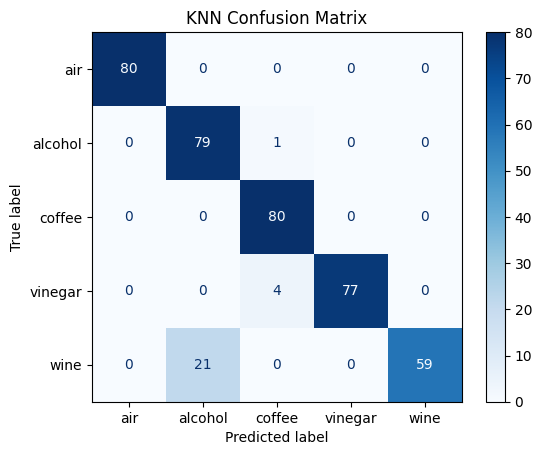

In [ ]:
# Cell 6: KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")
knn.fit(X_train_sc, y_train)

knn_pred = knn.predict(X_test_sc)
knn_acc  = accuracy_score(y_test, knn_pred)

start = time.perf_counter()
for _ in range(1000): knn.predict(X_test_sc[:1])
knn_latency_ms = (time.perf_counter() - start) * 1000 / 1000

knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean"))
knn_cv = cross_val_score(knn_pipeline, X, y, cv=5, scoring="accuracy")

print(f"KNN Accuracy:    {knn_acc:.3f}")
print(f"KNN CV:          {knn_cv.mean():.3f} +/- {knn_cv.std():.3f}")
print(f"KNN Latency:     {knn_latency_ms:.3f} ms")
print(classification_report(y_test, knn_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, knn_pred, labels=labels), display_labels=labels).plot(cmap="Blues")
plt.title("KNN Confusion Matrix"); plt.savefig("confusion_matrix_knn.png", dpi=150, bbox_inches="tight"); plt.show()

RF Accuracy:     0.948
RF CV:           0.886 +/- 0.057
RF Latency:      40.423 ms
              precision    recall  f1-score   support

         air       1.00      1.00      1.00        80
     alcohol       0.79      1.00      0.88        80
      coffee       1.00      1.00      1.00        80
     vinegar       1.00      1.00      1.00        81
        wine       1.00      0.74      0.85        80

    accuracy                           0.95       401
   macro avg       0.96      0.95      0.95       401
weighted avg       0.96      0.95      0.95       401



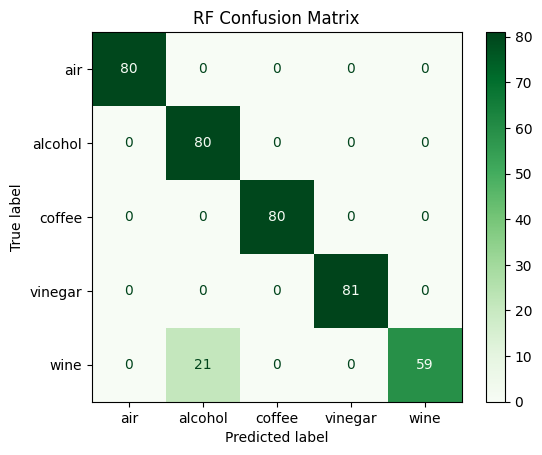

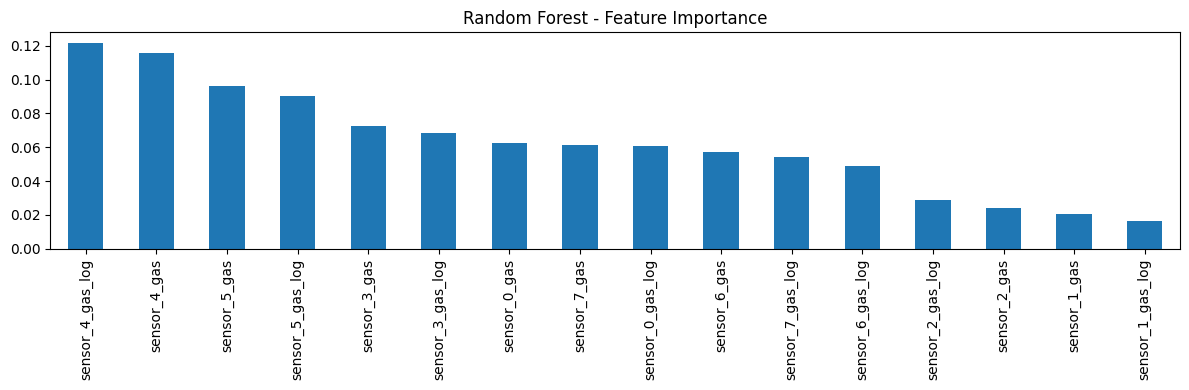

In [ ]:
# Cell 7: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42)
rf.fit(X_train_sc, y_train)

rf_pred = rf.predict(X_test_sc)
rf_acc  = accuracy_score(y_test, rf_pred)

start = time.perf_counter()
for _ in range(1000): rf.predict(X_test_sc[:1])
rf_latency_ms = (time.perf_counter() - start) * 1000 / 1000

rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42))
rf_cv = cross_val_score(rf_pipeline, X, y, cv=5, scoring="accuracy")

print(f"RF Accuracy:     {rf_acc:.3f}")
print(f"RF CV:           {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
print(f"RF Latency:      {rf_latency_ms:.3f} ms")
print(classification_report(y_test, rf_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred, labels=labels), display_labels=labels).plot(cmap="Greens")
plt.title("RF Confusion Matrix"); plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight"); plt.show()

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(12, 4))
importances.plot(kind="bar")
plt.title("Random Forest - Feature Importance"); plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()

SVM Accuracy:    0.900
SVM CV:          0.900 +/- 0.018
SVM Latency:     0.501 ms
              precision    recall  f1-score   support

         air       0.99      1.00      0.99        80
     alcohol       0.71      0.99      0.83        80
      coffee       1.00      0.91      0.95        80
     vinegar       0.98      1.00      0.99        81
        wine       0.91      0.60      0.72        80

    accuracy                           0.90       401
   macro avg       0.92      0.90      0.90       401
weighted avg       0.92      0.90      0.90       401



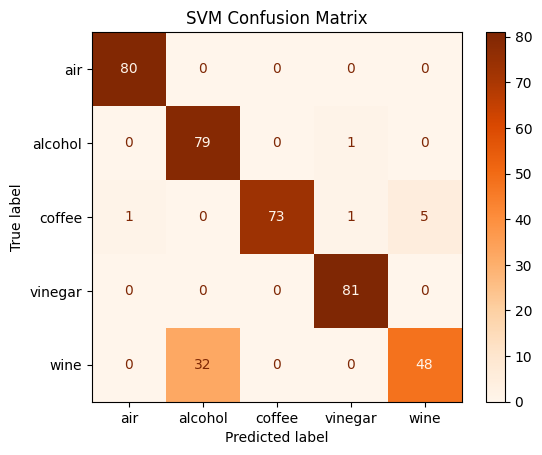

In [ ]:
# Cell 8: SVM Classifier
svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

svm_pred = svm.predict(X_test_sc)
svm_acc  = accuracy_score(y_test, svm_pred)

start = time.perf_counter()
for _ in range(1000): svm.predict(X_test_sc[:1])
svm_latency_ms = (time.perf_counter() - start) * 1000 / 1000

svm_pipeline = make_pipeline(MinMaxScaler(), SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42))
svm_cv = cross_val_score(svm_pipeline, X, y, cv=5, scoring="accuracy")

print(f"SVM Accuracy:    {svm_acc:.3f}")
print(f"SVM CV:          {svm_cv.mean():.3f} +/- {svm_cv.std():.3f}")
print(f"SVM Latency:     {svm_latency_ms:.3f} ms")
print(classification_report(y_test, svm_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred, labels=labels), display_labels=labels).plot(cmap="Oranges")
plt.title("SVM Confusion Matrix"); plt.savefig("confusion_matrix_svm.png", dpi=150, bbox_inches="tight"); plt.show()

NaN in X_train_sc: 0
Inf in X_train_sc: 0
MLP Accuracy:       0.713
MLP Latency:        0.286 ms per prediction
              precision    recall  f1-score   support

         air       1.00      0.62      0.77        80
     alcohol       0.71      0.97      0.82        80
      coffee       0.51      0.81      0.63        80
     vinegar       0.79      0.56      0.65        81
        wine       0.84      0.60      0.70        80

    accuracy                           0.71       401
   macro avg       0.77      0.71      0.71       401
weighted avg       0.77      0.71      0.71       401

MLP CV accuracy:    0.762 +/- 0.037
Per-fold:           [0.776 0.823 0.742 0.71  0.76 ]


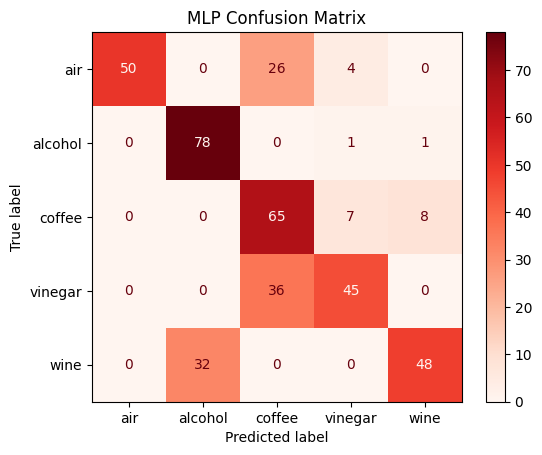

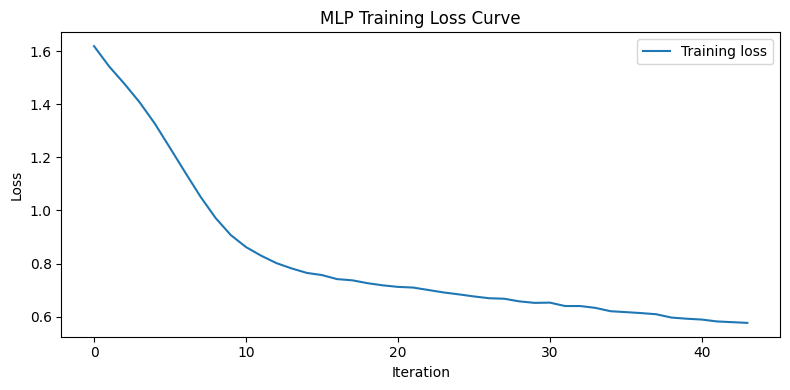

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Cell 9: MLP Neural Network
# Architecture: 16 inputs -> 128 -> 64 -> 32 -> 5 outputs
# ReLU activation with early stopping to prevent overfitting

# Ensure no NaN or inf values before training
print(f"NaN in X_train_sc: {np.isnan(X_train_sc).sum()}")
print(f"Inf in X_train_sc: {np.isinf(X_train_sc).sum()}")

X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)

# Encode target labels to numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
y_encoded = le.transform(y)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train_sc, y_train_encoded)

mlp_pred = mlp.predict(X_test_sc)
# Decode predictions back to original labels for reporting
mlp_pred_decoded = le.inverse_transform(mlp_pred)
mlp_acc = accuracy_score(y_test, mlp_pred_decoded)

# Latency benchmark
start = time.perf_counter()
for _ in range(1000):
    mlp.predict(X_test_sc[:1])
mlp_latency_ms = (time.perf_counter() - start) * 1000 / 1000

print(f"MLP Accuracy:       {mlp_acc:.3f}")
print(f"MLP Latency:        {mlp_latency_ms:.3f} ms per prediction")
print(classification_report(y_test, mlp_pred_decoded, target_names=labels))

# Cross-validation
mlp_pipeline = make_pipeline(
    MinMaxScaler(),
    MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu",
                  solver="adam", max_iter=500, early_stopping=True,
                  validation_fraction=0.1, random_state=42)
)
mlp_cv = cross_val_score(mlp_pipeline, X, y_encoded, cv=5, scoring="accuracy")
print(f"MLP CV accuracy:    {mlp_cv.mean():.3f} +/- {mlp_cv.std():.3f}")
print(f"Per-fold:           {mlp_cv.round(3)}")

# Confusion matrix
cm = confusion_matrix(y_test, mlp_pred_decoded, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Reds")
plt.title("MLP Confusion Matrix")
plt.savefig("confusion_matrix_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="Training loss")
if mlp.best_loss_ is not None:
    plt.axhline(y=mlp.best_loss_, color="r", linestyle="--", label="Best loss")
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("mlp_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Sequences built: (1957, 10, 16)  Labels: (1957,)
Epoch  10/50  Loss: 0.5557  Val Acc: 0.753
Epoch  20/50  Loss: 0.4879  Val Acc: 0.778
Epoch  30/50  Loss: 0.3966  Val Acc: 0.804
Epoch  40/50  Loss: 0.3577  Val Acc: 0.844
Epoch  50/50  Loss: 0.2975  Val Acc: 0.888
Best validation accuracy: 0.918
LSTM Accuracy:   0.918
LSTM Latency:    0.542 ms per sequence
              precision    recall  f1-score   support

         air       1.00      0.90      0.95        78
     alcohol       0.83      0.97      0.90        79
      coffee       0.90      0.92      0.91        78
     vinegar       0.94      1.00      0.97        79
        wine       0.95      0.79      0.87        78

    accuracy                           0.92       392
   macro avg       0.92      0.92      0.92       392
weighted avg       0.92      0.92      0.92       392



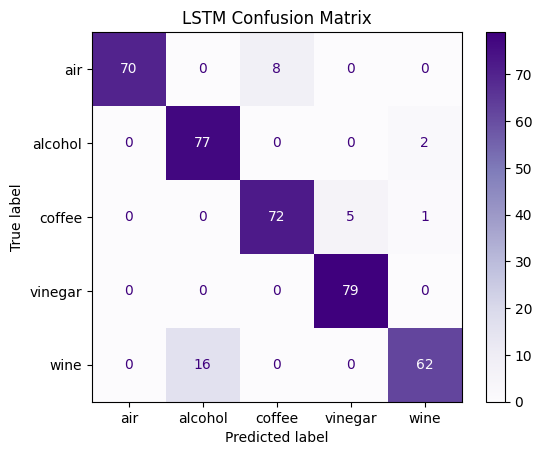

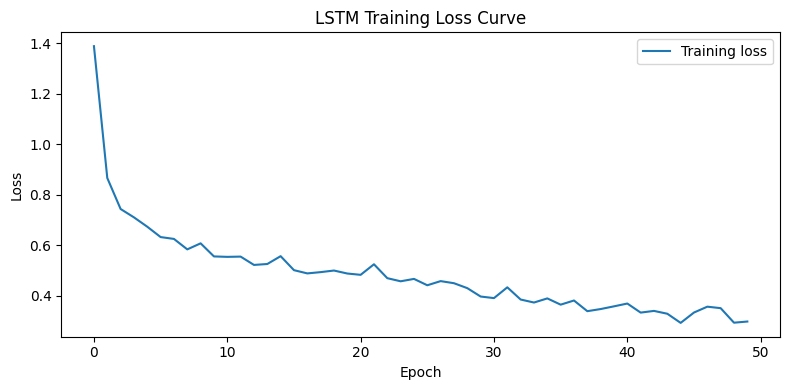

In [ ]:
# Cell 10: LSTM Neural Network
# Unlike other models which classify one snapshot at a time,
# LSTM takes a sequence of consecutive readings and learns how
# gas resistance changes over time as the smell diffuses into the sensor.

SEQ_LEN    = 10   # 10 consecutive readings = 5 seconds at 500ms intervals
N_FEATURES = len(feature_cols)  # 16 features per timestep
N_CLASSES  = len(labels)
EPOCHS     = 50
BATCH_SIZE = 32

# ── Label encoding (reuse le from MLP cell) ──────────────────────────────────
# le, y_enc already defined in Cell 9

# ── Build sequences from the scaled data ─────────────────────────────────────
# Group consecutive rows from the same class into sliding windows
def build_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len + 1):
        # Only create a sequence if all steps belong to the same class
        window_labels = y_arr[i:i + seq_len]
        if len(set(window_labels)) == 1:
            Xs.append(X_arr[i:i + seq_len])
            ys.append(window_labels[-1])
    return np.array(Xs), np.array(ys)

# Use full scaled dataset then split
X_all_sc = scaler.transform(X)
X_all_sc = np.nan_to_num(X_all_sc, nan=0.0, posinf=0.0, neginf=0.0)
y_all_enc = le.transform(y)

X_seq, y_seq = build_sequences(X_all_sc, y_all_enc, SEQ_LEN)
print(f"Sequences built: {X_seq.shape}  Labels: {y_seq.shape}")

X_seq_tr, X_seq_te, y_seq_tr, y_seq_te = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42,
    stratify=y_seq
)

# Convert to PyTorch tensors
X_tr_t = torch.FloatTensor(X_seq_tr).to(device)
y_tr_t = torch.LongTensor(y_seq_tr).to(device)
X_te_t = torch.FloatTensor(X_seq_te).to(device)
y_te_t = torch.LongTensor(y_seq_te).to(device)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)

# ── LSTM model definition ─────────────────────────────────────────────────────
class ENoseLSTM(nn.Module):
    def __init__(self, n_features, hidden_size, n_layers, n_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])  # take last timestep
        return self.fc(out)

lstm_model = ENoseLSTM(
    n_features=N_FEATURES,
    hidden_size=64,
    n_layers=2,
    n_classes=N_CLASSES,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses = []
best_val_acc = 0
best_state   = None

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validation accuracy
    lstm_model.eval()
    with torch.no_grad():
        val_preds = lstm_model(X_te_t).argmax(dim=1)
        val_acc   = (val_preds == y_te_t).float().mean().item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in lstm_model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.4f}  Val Acc: {val_acc:.3f}")

# Load best weights
lstm_model.load_state_dict(best_state)
print(f"Best validation accuracy: {best_val_acc:.3f}")

# ── Evaluation ───────────────────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    lstm_logits = lstm_model(X_te_t)
    lstm_pred_enc = lstm_logits.argmax(dim=1).cpu().numpy()

lstm_pred = le.inverse_transform(lstm_pred_enc)
lstm_true = le.inverse_transform(y_seq_te)
lstm_acc  = accuracy_score(lstm_true, lstm_pred)

# Latency benchmark (single sequence)
single_seq = torch.FloatTensor(X_seq_te[:1]).to(device)
start = time.perf_counter()
with torch.no_grad():
    for _ in range(1000): lstm_model(single_seq)
lstm_latency_ms = (time.perf_counter() - start) * 1000 / 1000

print(f"LSTM Accuracy:   {lstm_acc:.3f}")
print(f"LSTM Latency:    {lstm_latency_ms:.3f} ms per sequence")
print(classification_report(lstm_true, lstm_pred, target_names=labels))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(lstm_true, lstm_pred, labels=labels),
    display_labels=labels
).plot(cmap="Purples")
plt.title("LSTM Confusion Matrix")
plt.savefig("confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training loss")
plt.title("LSTM Training Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout()
plt.savefig("lstm_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# Store for comparison
lstm_cv_placeholder = best_val_acc  # LSTM uses its own val split


Ensemble Accuracy:  0.943
Ensemble Latency:   17.650 ms per prediction
              precision    recall  f1-score   support

         air       1.00      1.00      1.00        80
     alcohol       0.79      0.99      0.88        80
      coffee       0.98      1.00      0.99        80
     vinegar       1.00      0.99      0.99        81
        wine       1.00      0.74      0.85        80

    accuracy                           0.94       401
   macro avg       0.95      0.94      0.94       401
weighted avg       0.95      0.94      0.94       401

Ensemble CV accuracy: 0.935 +/- 0.011
Per-fold:             [0.928 0.943 0.952 0.922 0.928]


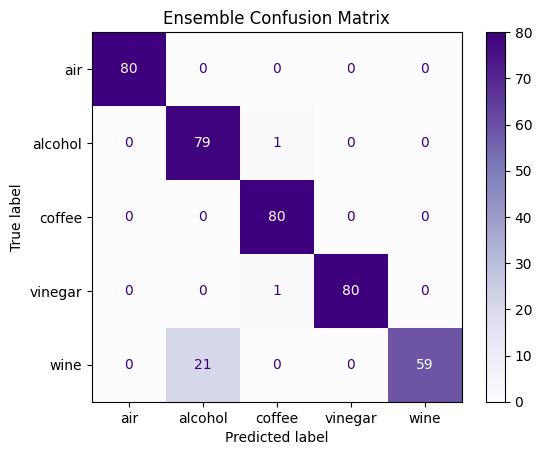

In [ ]:
# Cell 10: Voting Ensemble (KNN + RF + SVM + MLP)
# Soft voting averages the predicted probabilities from all three models
ensemble = VotingClassifier(
    estimators=[("knn", knn), ("rf", rf), ("svm", svm), ("mlp", mlp)],
    voting="soft"
)
ensemble.fit(X_train_sc, y_train)

ens_pred = ensemble.predict(X_test_sc)
ens_acc  = accuracy_score(y_test, ens_pred)

# Latency benchmark
start = time.perf_counter()
for _ in range(1000):
    ensemble.predict(X_test_sc[:1])
ens_latency_ms = (time.perf_counter() - start) * 1000 / 1000

print(f"Ensemble Accuracy:  {ens_acc:.3f}")
print(f"Ensemble Latency:   {ens_latency_ms:.3f} ms per prediction")
print(classification_report(y_test, ens_pred, target_names=labels))

ens_pipeline = make_pipeline(
    MinMaxScaler(),
    VotingClassifier(
        estimators=[
            ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")),
            ("rf",  RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42)),
            ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)),
            ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu", solver="adam", max_iter=500, early_stopping=True, validation_fraction=0.1, random_state=42))
        ],
        voting="soft"
    )
)
ens_cv = cross_val_score(ens_pipeline, X, y, cv=5, scoring="accuracy")
print(f"Ensemble CV accuracy: {ens_cv.mean():.3f} +/- {ens_cv.std():.3f}")
print(f"Per-fold:             {ens_cv.round(3)}")

cm = confusion_matrix(y_test, ens_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Purples")
plt.title("Ensemble Confusion Matrix")
plt.savefig("confusion_matrix_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

                Model  Accuracy  CV Mean   CV Std  Latency(ms)       Type
        Random Forest  0.947631 0.886102 0.057020    40.423153   Snapshot
Ensemble (KNN+RF+SVM)  0.942643 0.934565 0.011223    17.650044   Snapshot
                  KNN  0.935162 0.935559 0.012616     1.033652   Snapshot
                 LSTM  0.918367 0.918367 0.000000     0.541845 Sequential
                  SVM  0.900249 0.899620 0.018263     0.501373   Snapshot
                  MLP  0.713217 0.762201 0.037379     0.286317   Snapshot


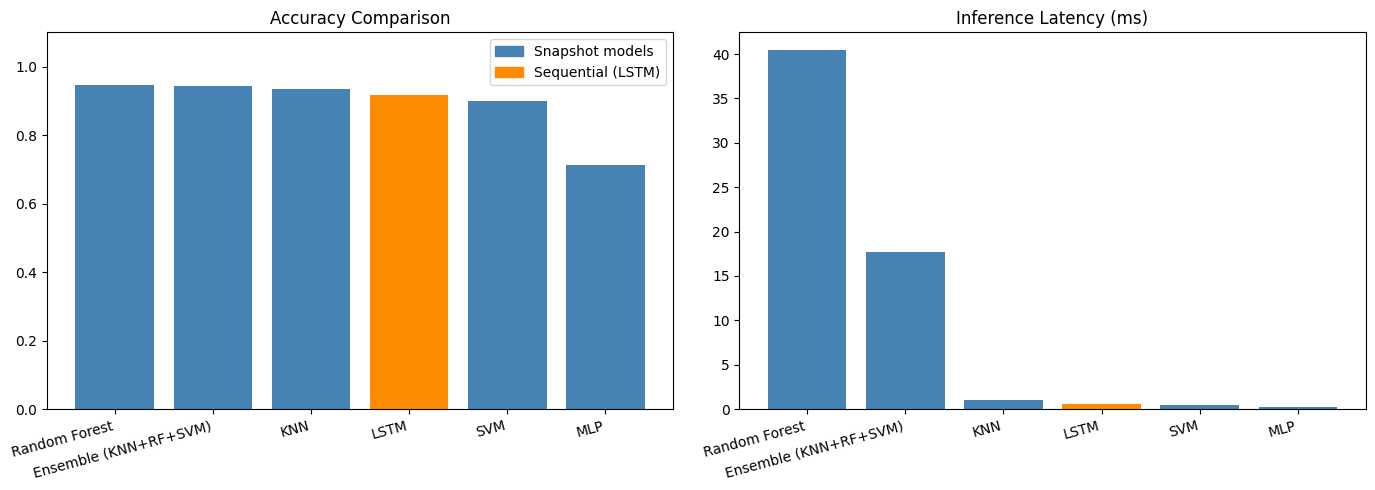

Note: LSTM CV std shown as 0.0 — uses internal train/val split rather than k-fold
Best snapshot model: Random Forest
Best overall:        Random Forest


In [ ]:
# Cell 12: Model Comparison
results = pd.DataFrame({
    "Model":       ["KNN", "Random Forest", "SVM", "MLP", "LSTM", "Ensemble (KNN+RF+SVM)"],
    "Accuracy":    [knn_acc, rf_acc, svm_acc, mlp_acc, lstm_acc, ens_acc],
    "CV Mean":     [knn_cv.mean(), rf_cv.mean(), svm_cv.mean(), mlp_cv.mean(), lstm_cv_placeholder, ens_cv.mean()],
    "CV Std":      [knn_cv.std(),  rf_cv.std(),  svm_cv.std(),  mlp_cv.std(),  0.0, ens_cv.std()],
    "Latency(ms)": [knn_latency_ms, rf_latency_ms, svm_latency_ms, mlp_latency_ms, lstm_latency_ms, ens_latency_ms],
    "Type":        ["Snapshot", "Snapshot", "Snapshot", "Snapshot", "Sequential", "Snapshot"],
})
results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue" if t=="Snapshot" else "darkorange" for t in results["Type"]]

axes[0].bar(results["Model"], results["Accuracy"], color=colors)
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(range(len(results["Model"]))) # Set explicit tick locations
axes[0].set_xticklabels(results["Model"], rotation=15, ha="right")
axes[0].legend(handles=[
    Rectangle((0,0),1,1, color="steelblue", label="Snapshot models"),
    Rectangle((0,0),1,1, color="darkorange", label="Sequential (LSTM)")
])

axes[1].bar(results["Model"], results["Latency(ms)"], color=colors)
axes[1].set_title("Inference Latency (ms)")
axes[1].set_xticks(range(len(results["Model"]))) # Set explicit tick locations
axes[1].set_xticklabels(results["Model"], rotation=15, ha="right")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Note: LSTM CV std shown as 0.0 — uses internal train/val split rather than k-fold")
print(f"Best snapshot model: {results[results["Type"] == "Snapshot"].iloc[0]["Model"]}")
print(f"Best overall:        {results.iloc[0]["Model"]}")

In [ ]:
# Cell 13: Save Models
# sklearn models
with open("enose_knn_model.pkl", "wb") as f: pickle.dump(knn, f)
with open("enose_rf_model.pkl",  "wb") as f: pickle.dump(rf,  f)
with open("enose_svm_model.pkl", "wb") as f: pickle.dump(svm, f)
with open("enose_mlp_model.pkl", "wb") as f: pickle.dump(mlp, f)
with open("enose_ensemble_model.pkl", "wb") as f: pickle.dump(ensemble, f)

# LSTM - save PyTorch state dict
torch.save({
    "model_state": lstm_model.state_dict(),
    "n_features":  N_FEATURES,
    "hidden_size": 64,
    "n_layers":    2,
    "n_classes":   N_CLASSES,
    "seq_len":     SEQ_LEN,
    "labels":      labels,
    "dropout":     0.3
}, "enose_lstm_model.pt")

# Shared scaler and feature list
with open("enose_scaler.pkl", "wb") as f: pickle.dump(scaler, f)
with open("enose_le.pkl",     "wb") as f: pickle.dump(le, f)
joblib.dump(feature_cols, "feature_columns.pkl")

print("All models saved.")

from google.colab import files
files.download("enose_knn_model.pkl")
files.download("enose_rf_model.pkl")
files.download("enose_svm_model.pkl")
files.download("enose_mlp_model.pkl")
files.download("enose_ensemble_model.pkl")
files.download("enose_lstm_model.pt")
files.download("enose_scaler.pkl")
files.download("enose_le.pkl")
files.download("feature_columns.pkl")